# Tabular regression exploratory analysis

Inspect the anonymized dataset, identify nonlinear relationships and compare baseline models with a sparse polynomial model. The hidden dataset is used only for schema validation and inference. Prior inspection of the complete labeled dataset suggested a target formula, so the holdout estimate is not fully blind to that hypothesis.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"task2_regression/regression.py").exists())
sys.path.insert(0, str(ROOT))
from task2_regression.regression import FEATURES, read_data, split_indices, experiment
frame = read_data(ROOT/"task2_regression/data/train.csv", training=True)
hidden = read_data(ROOT/"task2_regression/data/hidden_test.csv")
print("Shapes:", frame.shape, hidden.shape)
print("Missing:", frame.isna().sum().sum(), "Duplicates:", frame.duplicated().sum())

Shapes: (90000, 54) (10000, 53)


Missing: 0 Duplicates: 0


In [2]:
print(frame.describe().to_string())
print("Unique values:")
print(frame.nunique().to_string())

                  0             1             2             3             4             5             6             7             8             9            10            11            12            13            14            15            16            17            18            19            20            21            22            23            24            25            26            27            28            29            30            31            32            33            34            35            36            37            38            39            40            41            42            43            44            45            46            47            48            49            50            51            52        target
count  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.000000  90000.0

0           500
1           500
2           500
3           500
4           500
5           500
6           199
7         90000
8             2
9           500
10          500
11          500
12          500
13        90000
14        90000
15        90000
16        90000
17        90000
18        90000
19        90000
20        90000
21        90000
22        90000
23        90000
24        90000
25        90000
26        90000
27        90000
28        90000
29        90000
30        90000
31        90000
32        90000
33        90000
34        90000
35        90000
36        90000
37        90000
38        90000
39        90000
40        90000
41        90000
42        90000
43        90000
44        90000
45        90000
46        90000
47        90000
48        90000
49        90000
50        90000
51        90000
52        90000
target    90000


## Analysis on the training partition

Split the labeled rows before selecting features. Linear correlation can miss symmetric quadratic relationships; compare correlations with raw features and their squares.

In [3]:
train_idx, valid_idx, test_idx = split_indices(len(frame), 42)
dev = frame.iloc[train_idx]
linear = dev.corr()["target"].drop("target")
squared = dev[FEATURES].pow(2).corrwith(dev.target)
print("Top linear correlations:", linear.abs().nlargest(8).to_string())
print("Top squared correlations:", squared.abs().nlargest(8).to_string())

Top linear correlations: 7     0.013136
44    0.008459
39    0.007798
40    0.007135
31    0.006672
41    0.006526
49    0.006396
1     0.005966
Top squared correlations: 6     0.999950
7     0.012934
44    0.008896
11    0.006973
1     0.006624
39    0.006378
13    0.006118
31    0.006075


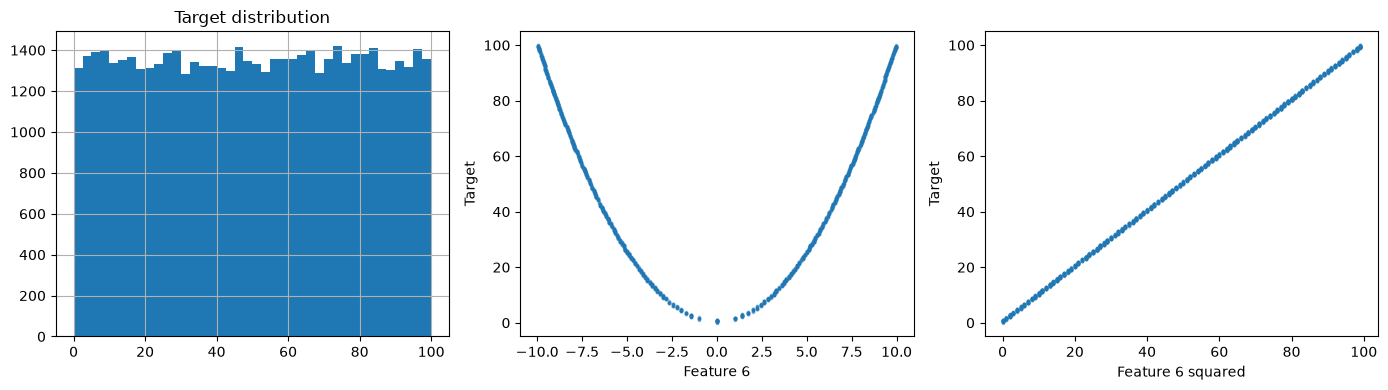

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize=(14,4))
dev.target.hist(bins=40, ax=axes[0]); axes[0].set_title("Target distribution")
sample = dev.sample(2500, random_state=42)
axes[1].scatter(sample["6"], sample.target, s=3, alpha=.3)
axes[1].set(xlabel="Feature 6", ylabel="Target")
axes[2].scatter(sample["6"]**2, sample.target, s=3, alpha=.3)
axes[2].set(xlabel="Feature 6 squared", ylabel="Target")
plt.tight_layout(); plt.show()

## Model selection and evaluation

Forward selection searches linear and squared features. Select the number of terms using validation RMSE, then evaluate on the separate holdout. Differences below 1e-10 are treated as numerical noise and the simpler model is preferred.

In [5]:
report, model = experiment(frame, seed=42)
print(pd.Series(report).to_string())

mean_validation_rmse                                                  28.916395
linear_validation_rmse                                                28.922429
seed                                                                         42
split_sizes                                               [54000, 18000, 18000]
candidates                    [{'terms': 1, 'validation_rmse': 0.28832020571...
selected_terms                                                         [6^2, 7]
terms                                                                         2
holdout_rmse                                                                0.0
holdout_max_absolute_error                                                  0.0


In [6]:
residual = dev.target - (dev["6"]**2 + dev["7"])
print("Formula max absolute error on training subset:", residual.abs().max())
print("Linear correlation for feature 6:", linear["6"])

Formula max absolute error on training subset: 5.684341886080802e-14
Linear correlation for feature 6: -0.001055943511286043


## Findings and limitations

Two selected terms reconstruct the target within floating-point precision. Feature provenance and availability at inference time must be checked before deployment. Hidden test labels are unavailable, so hidden-test RMSE cannot be measured.

After selecting model complexity, fit the final model on all 90,000 labeled rows. predictions.csv contains one target column in original hidden-test row order. Reproduce training and inference with task2_regression/train.py and task2_regression/predict.py.